In [174]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cv_f1_scores(models_dict, annotation_type, results_folder="./model_performance/drug_disease", save_dir="viz"):
    """
    Loads test F1 scores from 10-fold cross-validation results and plots a beeswarm chart.

    Parameters:
        models_dict (dict): Dictionary where keys are model folder names and values are short names to display.
        annotation_type (str): Annotation type to include in title and filename.
        results_folder (str): Path to the folder containing model result subfolders.
        save_dir (str): Directory where the plot image will be saved.
    """
    
    data = []

    for model_folder, shortname in models_dict.items():
        model_path = os.path.join(results_folder, model_folder)

        for i in range(10):  # 10-fold
            run_path = os.path.join(model_path, f'epochs_15_data_size_100_iter_{i}', 'test_results.json')

            if os.path.exists(run_path):
                with open(run_path, 'r') as file:
                    results = json.load(file)
                    data.append({
                        'model': shortname,
                        'run': i,
                        'test_f1': results['test_f1']
                    })
            else:
                print(f"File not found: {run_path}")

    df = pd.DataFrame(data)

    if not df.empty:
        if df.model.nunique() > 3:
            plt.figure(figsize=(12, 6))
        else:
            plt.figure(figsize=(8, 6))
        sns.swarmplot(x='model', y='test_f1', data=df, size=6, palette='Set2')

        means = df.groupby('model')['test_f1'].mean().reset_index()
        print(f"Mean F1 scores:\n{means}")
        sns.scatterplot(x='model', y='test_f1', data=means, 
                        color='grey', s=150, label='Mean', marker='D', edgecolor='black')

        title = f'10-fold CV Test F1 Scores ({annotation_type})'
        plt.title(title, fontsize=16)
        plt.xlabel('Model', fontsize=16)
        plt.ylabel('Test Micro-F1 Score', fontsize=16)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.ylim(0.5, 1)
        plt.grid(True, axis='y', linestyle='--', alpha=0.5)
        plt.legend(fontsize=12, loc='lower right')

        os.makedirs(save_dir, exist_ok=True)
        filename = f"cv_10_fold_models_F1_{annotation_type}.pdf"
        save_path = os.path.join(save_dir, filename)
        plt.savefig(save_path)
        plt.show()
        return df
    else:
        print("No valid data found to plot.")


In [206]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

def plot_cv_metrics(models_dict, annotation_type, panel_label="a", results_folder="./model_performance/drug_disease", save_dir="viz"):
    """
    Loads test precision, recall, and F1 scores from 10-fold cross-validation results
    and plots a beeswarm chart with metrics on the x-axis and models as legend entries.
    """

    data = []
    for model_folder, shortname in models_dict.items():
        model_path = os.path.join(results_folder, model_folder)

        for i in range(10):
            run_path = os.path.join(
                model_path,
                f'epochs_15_data_size_100_iter_{i}',
                'test_results.json'
            )

            if os.path.exists(run_path):
                with open(run_path, 'r') as file:
                    results = json.load(file)
                    data.append({
                        'model': shortname,
                        'run': i,
                        'precision': results.get('test_precision'),
                        'recall': results.get('test_recall'),
                        'f1': results.get('test_f1')
                    })
            else:
                print(f"File not found: {run_path}")

    df = pd.DataFrame(data)

    if df.empty:
        print("No valid data found to plot.")
        return None, None

    df_long = df.melt(
        id_vars=['model', 'run'],
        value_vars=['precision', 'recall', 'f1'],
        var_name='metric',
        value_name='score'
    )
    df_long['metric'] = df_long['metric'].str.title()
    # optional: drop missing values
    df_long = df_long.dropna(subset=['score'])

    means = (
        df_long.groupby(['model', 'metric'], as_index=False)['score']
        .mean()
    )

    width = max(8, 2 * df_long['model'].nunique())
    plt.figure(figsize=(width, 6))

    ax = sns.swarmplot(
        x='metric',
        y='score',
        hue='model',
        data=df_long,
        size=6,
        palette='Set2',
        dodge=True
    )

    # Manually overlay mean diamonds aligned with swarm dodge positions
    metric_order = ['Precision', 'Recall', 'F1']
    model_order = list(df_long['model'].drop_duplicates())
    n_models = len(model_order)

    # approximate dodge offsets similar to seaborn
    offsets = np.linspace(-0.25, 0.25, n_models) if n_models > 1 else [0]

    for metric_idx, metric in enumerate(metric_order):
        for model_idx, model in enumerate(model_order):
            row = means[(means['metric'] == metric) & (means['model'] == model)]
            if not row.empty:
                ax.scatter(
                    metric_idx + offsets[model_idx],
                    row['score'].iloc[0],
                    marker='D',
                    s=80,
                    color='black',
                    zorder=10
                )

    title_value = annotation_type.replace("_","/").title()
    title = f'10-fold CV Test Metrics ({title_value})'
    plt.title(title, fontsize=16)
    plt.xlabel('Metric', fontsize=16)
    plt.ylabel('Score', fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.ylim(0, 1)
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)

    handles, labels = ax.get_legend_handles_labels()
    # keep only one entry per model (swarmplot duplicates due to dodge)
    unique = dict(zip(labels, handles))
    handles = list(unique.values())
    labels = list(unique.keys())
    
    # add mean symbol (diamond)
    mean_handle = Line2D(
        [0], [0],
        marker='D',
        color='black',
        linestyle='None',
        markersize=8,
        label='Mean'
    )
    
    handles.append(mean_handle)
    labels.append('Mean')
    
    plt.legend(
        handles=handles,
        labels=labels,
        fontsize=12,
        title="Model",
        loc='lower right'
    )
    #plt.legend(handles[:len(model_order)], labels[:len(model_order)], fontsize=12, title="Model", loc='lower right')
    fig = plt.gcf()
    
    fig.text(
        0.08, 0.93, panel_label,   # x, y (figure coordinates)
        ha="right",
        va="bottom",
        fontsize=16,
        fontweight="bold"
    )
    os.makedirs(save_dir, exist_ok=True)
    filename = f"cv_10_fold_models_metrics_{annotation_type}.pdf"
    save_path = os.path.join(save_dir, filename)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    return df_long, means

### DRUG and DISEASE

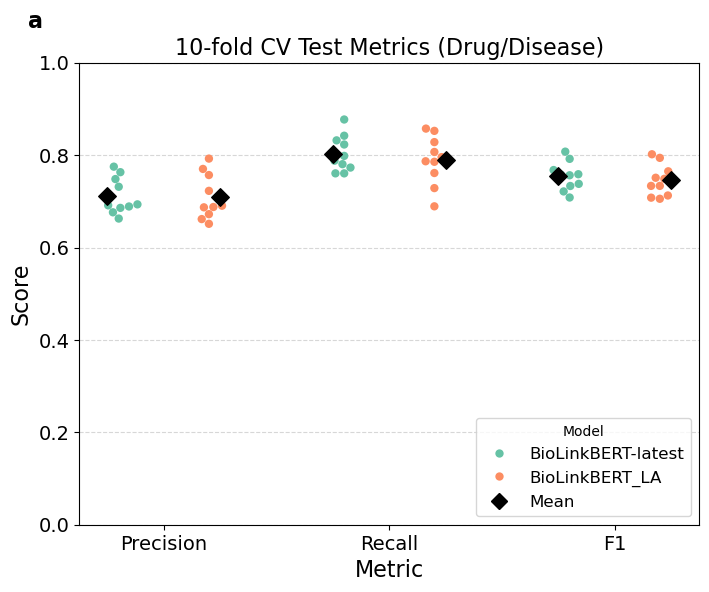

In [209]:
models = {
    'michiyasunaga_biolinkbert': 'BioLinkBERT-latest',
    'label_all_michiyasunaga_BioLinkBERT-base': 'BioLinkBERT_LA',
}

df, means = plot_cv_metrics(models_dict=models, annotation_type="drug_disease")

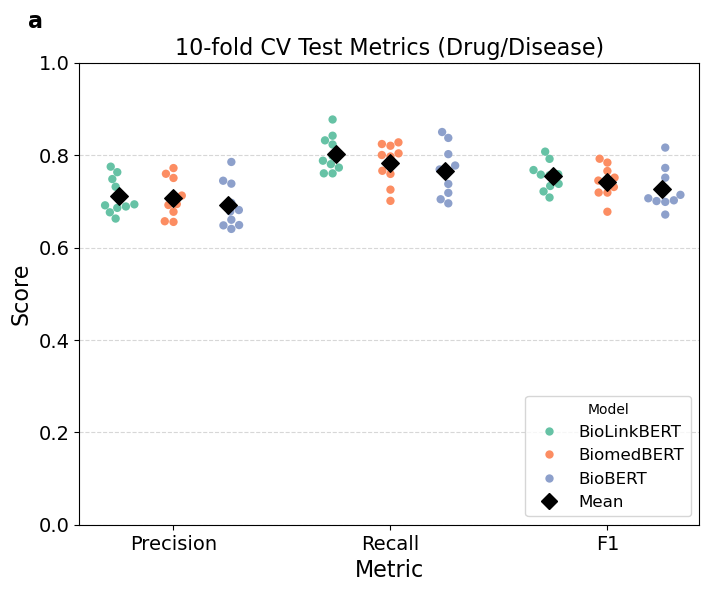

In [211]:
models = {
    'michiyasunaga_biolinkbert': 'BioLinkBERT',
    'microsoft_BiomedBERT-base-uncased-abstract-fulltext': 'BiomedBERT',
    'biobert-v1.1': 'BioBERT',
    
}

df, means_drug_disease = plot_cv_metrics(models_dict=models, annotation_type="drug_disease", results_folder="./model_performance/drug_disease")

In [213]:
means_drug_disease

,model,metric,score
0,BioBERT,F1,0.726131
1,BioBERT,Precision,0.692092
2,BioBERT,Recall,0.765815
3,BioLinkBERT,F1,0.754060
4,BioLinkBERT,Precision,0.711613
5,BioLinkBERT,Recall,0.803480
6,BiomedBERT,F1,0.742637
7,BiomedBERT,Precision,0.708096
8,BiomedBERT,Recall,0.782470


In [215]:
print(f"recall: {df[(df['model'] == 'BioLinkBERT') & (df['metric'] == 'recall')]['score'].mean()}")
print(f"precision: {df[(df['model'] == 'BioLinkBERT') & (df['metric'] == 'precision')]['score'].mean()}")
print(f"f1: {df[(df['model'] == 'BioLinkBERT') & (df['metric'] == 'f1')]['score'].mean()}")


recall: nan
precision: nan
f1: nan


Mean F1 scores:
            model   test_f1
0         BioBERT  0.726131
1     BioLinkBERT  0.754060
2  BioLinkBERT_IO  0.745995
3  BioLinkBERT_LA  0.745359
4      BiomedBERT  0.742637
5   BiomedBERT_LA  0.743788


/var/folders/nd/2fzvhsh510gbt9x6z5pdb1gr0000gn/T/ipykernel_24431/3516406597.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='model', y='test_f1', data=df, size=6, palette='Set2')


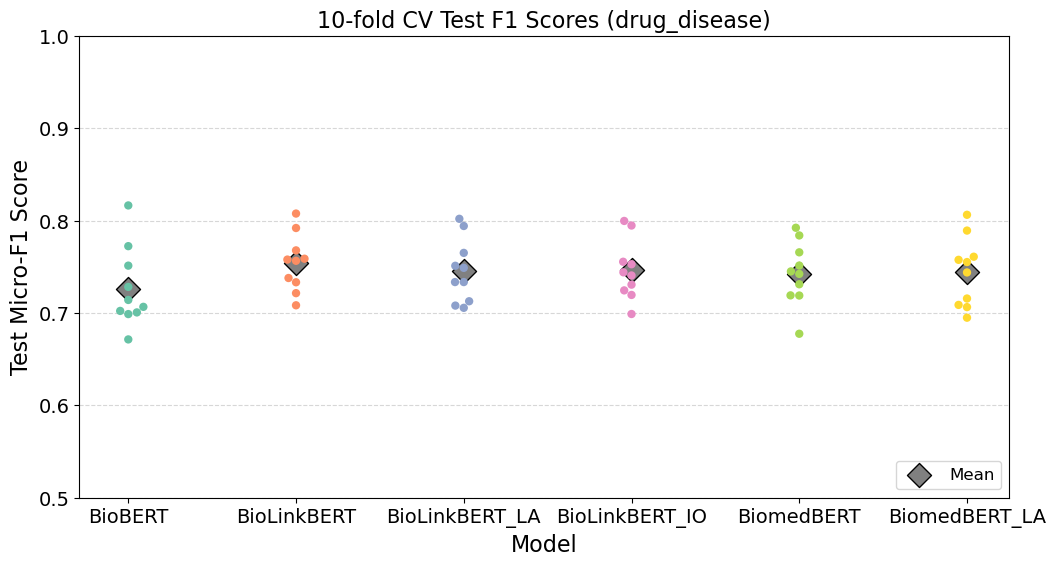

In [217]:
models = {
    'biobert-v1.1': 'BioBERT',
    'michiyasunaga_biolinkbert': 'BioLinkBERT',
    #'michiyasunaga_BioLinkBERT-base': 'BioLinkBERT-latest',
    'label_all_michiyasunaga_BioLinkBERT-base': 'BioLinkBERT_LA',
    'label_all_michiyasunaga_BioLinkBERT-base-IO': 'BioLinkBERT_IO',
    'microsoft_BiomedBERT-base-uncased-abstract-fulltext': 'BiomedBERT',
    'label_all_microsoft_BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext': 'BiomedBERT_LA'
}

df = plot_cv_f1_scores(models_dict=models, annotation_type="drug_disease")


In [219]:
min_performance = df.loc[df.groupby('model')['test_f1'].idxmin()].reset_index(drop=True)
max_performance = df.loc[df.groupby('model')['test_f1'].idxmax()].reset_index(drop=True)

min_performance

,model,run,test_f1
0,BioBERT,1,0.671329
1,BioLinkBERT,1,0.708261
2,BioLinkBERT_IO,1,0.698824
3,BioLinkBERT_LA,9,0.705513
4,BiomedBERT,1,0.677458
5,BiomedBERT_LA,2,0.694832


In [221]:
max_performance

,model,run,test_f1
0,BioBERT,8,0.816327
1,BioLinkBERT,8,0.807543
2,BioLinkBERT_IO,8,0.799543
3,BioLinkBERT_LA,8,0.801859
4,BiomedBERT,3,0.792173
5,BiomedBERT_LA,3,0.806206


In [223]:
median_f1 = df.groupby('model')['test_f1'].median().reset_index()

# For each model, find the run that has the test_f1 closest to the median
def find_median_run(group):
    median_value = median_f1[median_f1['model'] == group.name]['test_f1'].values[0]
    closest_idx = (group['test_f1'] - median_value).abs().idxmin()
    return group.loc[closest_idx]

# Apply the function to find the median run for each model
median_performance = df.groupby('model').apply(find_median_run).reset_index(drop=True)
median_performance

,model,run,test_f1
0,BioBERT,7,0.714034
1,BioLinkBERT,4,0.757745
2,BioLinkBERT_IO,4,0.743941
3,BioLinkBERT_LA,0,0.733398
4,BiomedBERT,4,0.744935
5,BiomedBERT_LA,0,0.743812


## Strain

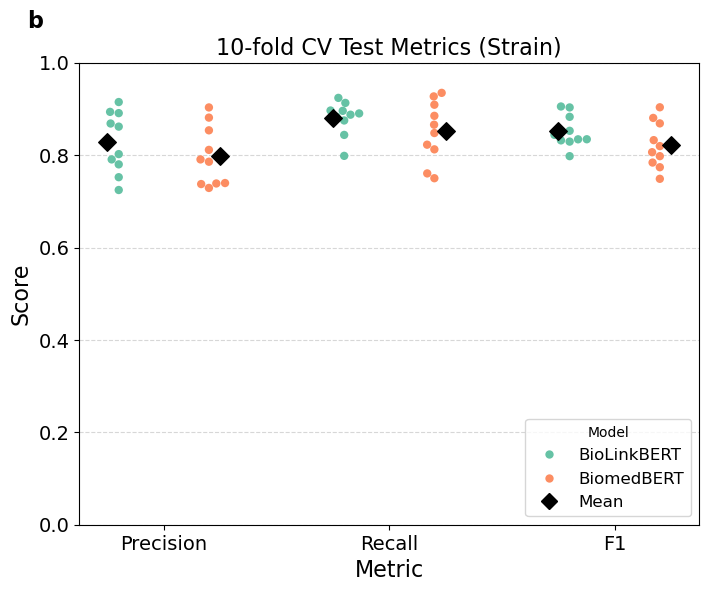

In [226]:
models = {
    'michiyasunaga_BioLinkBERT-base': 'BioLinkBERT',
    'microsoft_BiomedNLP-BiomedBERT-base-uncased-abstract': 'BiomedBERT'
    #'microsoft_BiomedBERT-base-uncased-abstract-fulltext': 'BiomedBERT',
    
}

df, means_strain = plot_cv_metrics(models_dict=models, annotation_type="strain", panel_label="b", results_folder="./model_performance/strain")

In [200]:
means_strain

,model,metric,score
0,BioLinkBERT,F1,0.851547
1,BioLinkBERT,Precision,0.827914
2,BioLinkBERT,Recall,0.880734
3,BiomedBERT,F1,0.821521
4,BiomedBERT,Precision,0.797037
5,BiomedBERT,Recall,0.851519


# Animals nr

/var/folders/nd/2fzvhsh510gbt9x6z5pdb1gr0000gn/T/ipykernel_24431/670991006.py:55: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(


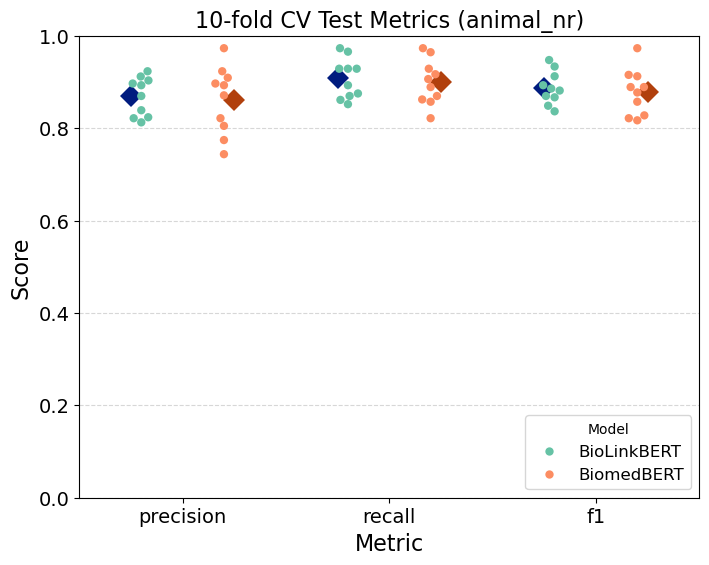

In [51]:
models = {
    'michiyasunaga_BioLinkBERT-base': 'BioLinkBERT',
    'microsoft_BiomedNLP-BiomedBERT-base-uncased-abstract': 'BiomedBERT'
    #'microsoft_BiomedBERT-base-uncased-abstract-fulltext': 'BiomedBERT',
    
}

df, means_animal_nr = plot_cv_metrics(models_dict=models, annotation_type="animal_nr", results_folder="./model_performance/animal_nr")

In [25]:
print(f"recall: {df[(df['model'] == 'BioLinkBERT') & (df['metric'] == 'recall')]['score'].mean()}")
print(f"precision: {df[(df['model'] == 'BioLinkBERT') & (df['metric'] == 'precision')]['score'].mean()}")
print(f"f1: {df[(df['model'] == 'BioLinkBERT') & (df['metric'] == 'f1')]['score'].mean()}")


recall: 0.9074589823277979
precision: 0.86932091804099
f1: 0.8873990185821625
